In [ ]:
!pip install -q transformers==4.20.0
!pip install -q pytorch-lightning
!pip install -q roboflow

In [ ]:
from huggingface_hub import login
from google.colab import userdata
token = userdata.get('Nyi_token')
login(token=token)

In [ ]:
import os
import random
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch
import torchvision
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pycocotools.coco import COCO
from transformers import YolosImageProcessor
from transformers import DetrConfig, YolosForObjectDetection
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Hugging Face

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [ ]:
class CocoDetection(torchvision.datasets.CocoDetection):
    def __init__(self, img_folder, feature_extractor, train=True):
        ann_file = os.path.join(img_folder, "_annotations.coco.json")
        super(CocoDetection, self).__init__(img_folder, ann_file)
        self.feature_extractor = feature_extractor

    def __getitem__(self, idx):
        # read in PIL image and target in COCO format
        img, target = super(CocoDetection, self).__getitem__(idx)

        # preprocess image and target (converting target to DETR format, resizing + normalization of both image and target)
        image_id = self.ids[idx]
        target = {'image_id': image_id, 'annotations': target}
        encoding = self.feature_extractor(images=img, annotations=target, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze() # remove batch dimension
        target = encoding["labels"][0] # remove batch dimension

        return pixel_values, target

In [ ]:
feature_extractor = YolosImageProcessor.from_pretrained("hustvl/yolos-small", size=512, max_size=864)

train_dataset = CocoDetection(img_folder=("markerpensseg/train"), feature_extractor=feature_extractor)
val_dataset = CocoDetection(img_folder=("markerpensseg/valid"), feature_extractor=feature_extractor, train=False)

print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(val_dataset))

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Number of training examples: 225
Number of validation examples: 30


Image ID : 90


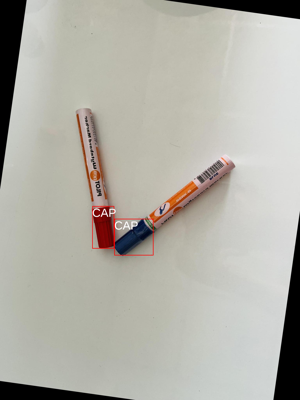

In [ ]:
image_ids = train_dataset.coco.getImgIds()
image_id = image_ids[np.random.randint(0, len(image_ids))]
print('Image ID : {}'.format(image_id))
image = train_dataset.coco.loadImgs(image_id)[0]
image = Image.open(os.path.join("markerpensseg/train", image['file_name']))

annotations = train_dataset.coco.imgToAnns[image_id]
draw = ImageDraw.Draw(image, "RGBA")

cats = train_dataset.coco.cats
id2label = {k: v['name'] for k,v in cats.items()}

font_path = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"
font = ImageFont.truetype(font_path, 60) # Increased font size for better visibility

for annotation in annotations:
  box = annotation['bbox']
  class_idx = annotation['category_id']
  x,y,w,h = tuple(box)
  draw.rectangle((x,y,x+w,y+h), outline='red', width=3)
  draw.text((x, y), id2label[class_idx], fill='white', font=font)

width, height = image.size
target_width = 300
ratio = target_width / width
target_height = int(height * ratio)

image.resize((target_width, target_height))

In [ ]:
def collate_fn(batch):
  pixel_values = [item[0] for item in batch]
  encoding = feature_extractor.pad(pixel_values, return_tensors="pt")
  labels = [item[1] for item in batch]
  batch = {}
  batch['pixel_values'] = encoding['pixel_values']
  batch['labels'] = labels
  return batch

train_dataloader = DataLoader(train_dataset, collate_fn=collate_fn, batch_size=4, shuffle=True)
val_dataloader = DataLoader(val_dataset, collate_fn=collate_fn, batch_size=4, shuffle=False)
batch = next(iter(train_dataloader))

In [ ]:
class YoloS(pl.LightningModule):

     def __init__(self, lr, weight_decay):
         super().__init__()
         # replace COCO classification head with custom head
         self.model = YolosForObjectDetection.from_pretrained("hustvl/yolos-small",
                                                             num_labels=len(id2label),
                                                             ignore_mismatched_sizes=True)
         self.lr = lr
         self.weight_decay = weight_decay
         self.save_hyperparameters()  # adding this will save the hyperparameters to W&B too

     def forward(self, pixel_values):
       outputs = self.model(pixel_values=pixel_values)

       return outputs

     def common_step(self, batch, batch_idx):
       pixel_values = batch["pixel_values"]
       labels = [{k: v.to(self.device) for k, v in t.items()} for t in batch["labels"]]

       outputs = self.model(pixel_values=pixel_values, labels=labels)

       loss = outputs.loss
       loss_dict = outputs.loss_dict

       return loss, loss_dict

     def training_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        # logs metrics for each training_step,
        # and the average across the epoch
        self.log("train/loss", loss)
        for k,v in loss_dict.items():
          self.log("train/" + k, v.item())

        return loss

     def validation_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        self.log("validation/loss", loss)
        for k,v in loss_dict.items():
          self.log("validation/" + k, v.item())

        return loss

     def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr,
                                  weight_decay=self.weight_decay)

        return optimizer

     def train_dataloader(self):
        return train_dataloader

     def val_dataloader(self):
        return val_dataloader

In [ ]:
#initialize the model
model = YoloS(lr=2.5e-5, weight_decay=1e-4)

In [ ]:
# Keep track of the checkpoint with the lowest validation loss
checkpoint_callback = ModelCheckpoint(
    monitor="validation/loss", mode="min",
    filename="ckpt_{epoch:03d}-vloss_{valid/loss:.4f}",
    auto_insert_metric_name=False,
)

In [ ]:
trainer = Trainer(accelerator='gpu', devices=1, max_epochs=30, gradient_clip_val=0.1, accumulate_grad_batches=8,
                 callbacks=[checkpoint_callback], log_every_n_steps=5) #  , logger=wandb_logger
# trainer.fit(model)

# Resume
trainer.fit(model, ckpt_path="lightning_logs/version_0/checkpoints/ckpt_009-vloss_0.0000.ckpt")

In [ ]:
# INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
# INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
# INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
# /usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face/lightning_logs/version_0/checkpoints exists and is not empty.
# INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at lightning_logs/version_0/checkpoints/ckpt_009-vloss_0.0000.ckpt
# INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
# ┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
# ┃   ┃ Name  ┃ Type                    ┃ Params ┃ Mode ┃ FLOPs ┃
# ┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
# │ 0 │ model │ YolosForObjectDetection │ 30.7 M │ eval │     0 │
# └───┴───────┴─────────────────────────┴────────┴──────┴───────┘
# Trainable params: 30.7 M
# Non-trainable params: 0
# Total params: 30.7 M
# Total estimated model params size (MB): 122
# Modules in train mode: 0
# Modules in eval mode: 225
# Total FLOPs: 0
# INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at lightning_logs/version_0/checkpoints/ckpt_009-vloss_0.0000.ckpt
# Epoch 29/29 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57/57 0:00:35 • 0:00:00 1.58it/s v_num: 1.000
# /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
# is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
# /usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 226 module(s) in eval mode
# at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can
# ignore this warning.
# INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.

In [ ]:
# Get the path of the best saved model.
CKPT_PATH = checkpoint_callback.best_model_path
CKPT_PATH

'/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face/lightning_logs/version_0/checkpoints/ckpt_021-vloss_0.0000.ckpt'

In [ ]:
# CKPT_PATH = 'lightning_logs/version_0/checkpoints/ckpt_021-vloss_0.0000.ckpt'

In [ ]:
model = YoloS.load_from_checkpoint(CKPT_PATH)

In [ ]:
#clean up torch tensors
torch.cuda.empty_cache()

In [ ]:
#we borrow the eval scripts from the DETR repo as they provide similar functionality to calculate mAP
!git clone https://github.com/facebookresearch/detr.git

fatal: destination path 'detr' already exists and is not an empty directory.


In [ ]:
%cd /content/gdrive/MyDrive/Hugging Face/

/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [ ]:
from detr import *

In [ ]:
from detr.datasets import get_coco_api_from_dataset
base_ds = get_coco_api_from_dataset(val_dataset)

In [ ]:
from detr.datasets.coco_eval import CocoEvaluator
from tqdm.notebook import tqdm

iou_types = ['bbox']
coco_evaluator = CocoEvaluator(base_ds, iou_types) # initialize evaluator with ground truths

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def post_process_predictions_for_coco(outputs, original_labels, threshold=0.5):
    """
    Prepares raw model outputs for COCO evaluation by converting them into the format
    expected by detr's coco_eval.py.

    Args:
        outputs (transformers.modeling_outputs.ObjectDetectionOutput): Raw outputs from the model.
        original_labels (list[dict]): The original labels from the batch, containing 'image_id' and 'orig_size'.
        threshold (float): Confidence threshold to filter predictions.
    Returns:
        dict: A dictionary where keys are image_ids and values are dictionaries containing
              'boxes' (normalized cxcywh tensors), 'scores' (tensors), and 'labels' (tensors).
              This is the input format expected by detr's `prepare_for_coco_detection` function.
    """
    pred_logits = outputs.logits
    pred_boxes = outputs.pred_boxes

    res = {} # This will store image_id -> {'boxes': tensor, 'scores': tensor, 'labels': tensor}
    for batch_idx in range(len(original_labels)):
        original_img_id = original_labels[batch_idx]['image_id'].item()
        original_img_size = original_labels[batch_idx]['orig_size'] # [height, width]
        img_h, img_w = original_img_size[0].item(), original_img_size[1].item()

        # Get probabilities, excluding the 'no object' class (last one)
        probas_all_queries = pred_logits[batch_idx].softmax(-1)
        probas_object_classes = probas_all_queries[:, :-1] # Exclude the last column (no object)

        # Keep predictions with confidence > threshold
        scores, labels = probas_object_classes.max(-1) # Max probability and corresponding class for each query
        keep = scores > threshold

        # Filter boxes, scores, and labels
        # Convert cxcywh to xyxy format as expected by COCOEvaluator
        boxes_filtered_normalized_xyxy = box_cxcywh_to_xyxy(pred_boxes[batch_idx, keep])

        # Rescale boxes to original image dimensions
        boxes_filtered_scaled_xyxy = boxes_filtered_normalized_xyxy * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32, device=boxes_filtered_normalized_xyxy.device)

        scores_filtered = scores[keep]
        labels_filtered = labels[keep]

        # Store in the format expected by detr's coco_eval.py
        res[original_img_id] = {
            'boxes': boxes_filtered_scaled_xyxy,
            'scores': scores_filtered,
            'labels': labels_filtered,
        }

    return res

print("Running evaluation...")

for idx, batch in enumerate(tqdm(val_dataloader)):
    # get the inputs
    pixel_values = batch["pixel_values"].to(device)
    labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]] # These are the ground truth labels from the dataset

    # forward pass
    outputs = model.model(pixel_values=pixel_values)

    # Use the custom post-processing function
    # results_for_batch will be a dict: {image_id: {'boxes': tensor, 'scores': tensor, 'labels': tensor}}
    results_for_batch = post_process_predictions_for_coco(outputs, labels, threshold=0.5)

    # coco_evaluator.update expects a dict where keys are image_ids and values are dictionaries
    # containing 'boxes', 'scores', 'labels' tensors. This format is now produced by our function.
    coco_evaluator.update(results_for_batch)

coco_evaluator.synchronize_between_processes()
coco_evaluator.accumulate()
coco_evaluator.summarize()

In [ ]:
# Running evaluation...
# 100%
#  8/8 [00:03<00:00,  2.42it/s]
# Accumulating evaluation results...
# DONE (t=0.01s).
# IoU metric: bbox
#  Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.515
#  Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.676
#  Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.603
#  Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
#  Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
#  Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.515
#  Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.313
#  Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.647
#  Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.647
#  Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
#  Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
#  Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.647

In [ ]:
CONFIDENCE=0.5

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

def plot_results(pil_img, prob, boxes):
    plt.figure(figsize=(6,6))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=2))
        cl = p.argmax()
        text = f'{id2label[cl.item()]}: {p[cl]:0.2f}'
        ax.text(xmin+12, ymin-25, text, fontsize=10,
                bbox=dict(facecolor='white', alpha=0.5))
    plt.axis('off')
    plt.show()

def visualize_predictions(image, outputs, threshold=CONFIDENCE):
  # keep only predictions with confidence >= threshold
  probas = outputs.logits.softmax(-1)[0, :, :-1]
  keep = probas.max(-1).values > threshold

  # convert predicted boxes from [0; 1] to image scales
  bboxes_scaled = rescale_bboxes(outputs.pred_boxes[0, keep].cpu(), image.size)

  # plot results
  plot_results(image, probas[keep], bboxes_scaled)

In [ ]:
pixel_values, target = val_dataset[7]
pixel_values = pixel_values.unsqueeze(0).to(device)
outputs = model(pixel_values=pixel_values)

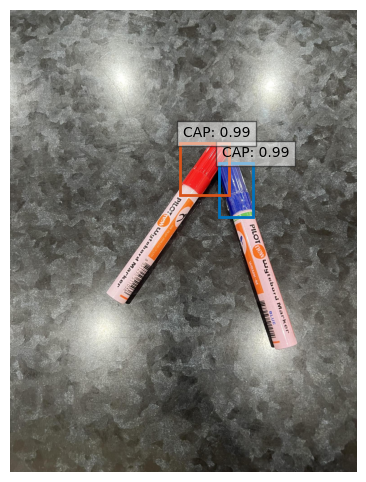

In [ ]:
image_id = target['image_id'].item()
image = val_dataset.coco.loadImgs(image_id)[0]
image = Image.open(os.path.join("markerpensseg/valid", image['file_name']))

visualize_predictions(image, outputs)

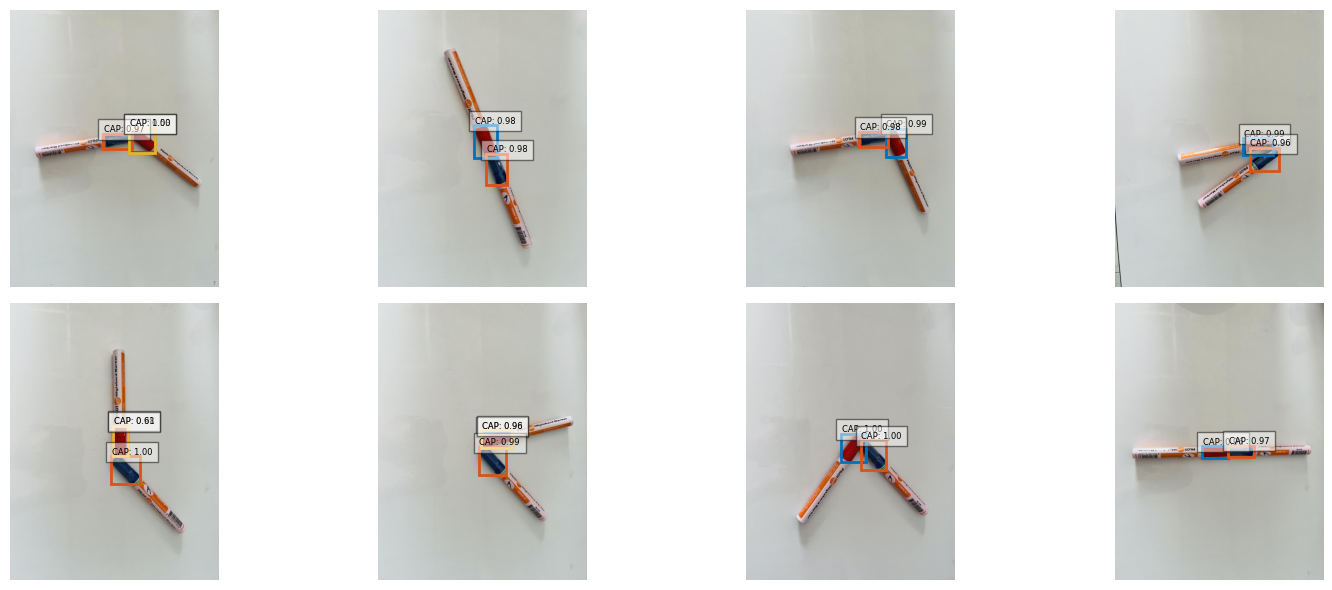

In [ ]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image_path in enumerate(sample_imgs):
    plt.subplot(rows, cols, ii + 1)

    # Load image using PIL for consistency with feature_extractor
    pil_img = Image.open(image_path).convert("RGB")

    # prepare image for the model
    inputs = feature_extractor(images=pil_img, return_tensors="pt")

    # Move inputs to the device
    inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

    # forward pass (no need for gradients at inference time)
    with torch.no_grad():
        outputs = model(**inputs)

        # keep only predictions with confidence >= threshold
        probas = outputs.logits.softmax(-1)[0, :, :-1]
        keep = probas.max(-1).values > CONFIDENCE # Use global CONFIDENCE

        # convert predicted boxes from [0; 1] to image scales
        bboxes_scaled = rescale_bboxes(outputs.pred_boxes[0, keep].cpu(), pil_img.size)

        ax = plt.gca()
        # Draw the original image first
        ax.imshow(pil_img)

        # Plot results
        colors_for_plot = COLORS * 100 # Use the global COLORS
        for p, (xmin, ymin, xmax, ymax), c in zip(probas[keep], bboxes_scaled.tolist(), colors_for_plot):
            ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                       fill=False, edgecolor=c, linewidth=2))
            cl = p.argmax()
            text = f'{id2label[cl.item()]}: {p[cl]:0.2f}' # Use global id2label
            ax.text(xmin +6, ymin -12, text, fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.5))

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 21.6 MB/s eta 0:00:00


In [ ]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 1.3 MB/s eta 0:00:00


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [ ]:
model = model.to(device)
dummy_input = torch.randn(1, 3, 800, 800).to(device)

In [ ]:
onnx_model_path = "lightning_logs/yolos.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    opset_version=16,
    input_names=["input"],
    output_names=["boxes"],
    dynamic_axes={
        "input": {0: "batch_size", 2: "height", 3: "width"},
        "boxes": {0: "num_boxes"},
    },
    do_constant_folding=True,
)
print(f"ONNX export {onnx_model_path} completed successfully!")

/tmp/ipykernel_9701/283876357.py:2: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0322 19:33:29.988000 9701 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 16 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0322 19:33:30.746000 9701 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, ali

[torch.onnx] Obtain model graph for `YoloS([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `YoloS([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:65: adapter_lookup: Assertion `false`

[torch.onnx] Translate the graph into ONNX... ✅
Applied 52 of general pattern rewrite rules.
ONNX export lightning_logs/yolos.onnx completed successfully!


In [ ]:
import onnxruntime
import numpy as np
import cv2
import torch
import os
import random

# Load image and preprocess
img_path = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg"

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (800, 800))
img_input = (img_resized[:, :, ::-1].astype(np.float32) ) / 255
img_input = (img_input - mean) / std
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("lightning_logs/yolos.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(1, 100, 3), (1, 100, 4), (1, 2601, 384)]


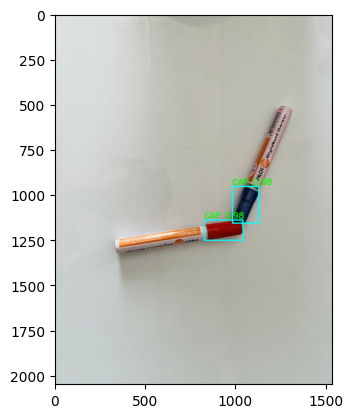

In [ ]:
import cv2
import numpy as np
import os
import random
from matplotlib import pyplot as plt

# Class labels
CLASS_LABELS = ["", "CAP"]

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

def visualize_results(img_orig, outputs, threshold=0.8):
    h, w = img_orig.shape[:2]
    annotated_img = img_orig.copy()

    final_cls_logits = outputs[0][0]   # Shape: (100, 3)
    final_boxes = outputs[1][0]        # Shape: (100, 4) -> [cx, cy, bw, bh] normalized

    # Get probabilities for all 100 queries
    probs = softmax(final_cls_logits)

    # In YOLOS/DETR, the last column is usually the "Background" class
    scores = np.max(probs[:, :-1], axis=1)
    labels = np.argmax(probs[:, :-1], axis=1)

    keep_indices = np.where(scores > threshold)[0]

    for idx in keep_indices:
        score = scores[idx]
        label = labels[idx]
        labeltext = CLASS_LABELS[label]

        if label == 0: continue

        # YOLOS Box Decoding: [center_x, center_y, width, height] -> [x1, y1, x2, y2]
        cx, cy, bw, bh = final_boxes[idx]

        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)

        # Clip coordinates to image size
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        color = (0, 255, 0)

        # Draw the bounding box and text
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (255, 255, 0), 5)
        cv2.putText(annotated_img, f"{labeltext} {score:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)

    return annotated_img

# EXECUTE
result_viz = visualize_results(img, outputs, threshold=0.5)
plt.imshow(cv2.cvtColor(result_viz, cv2.COLOR_BGR2RGB))
plt.show()

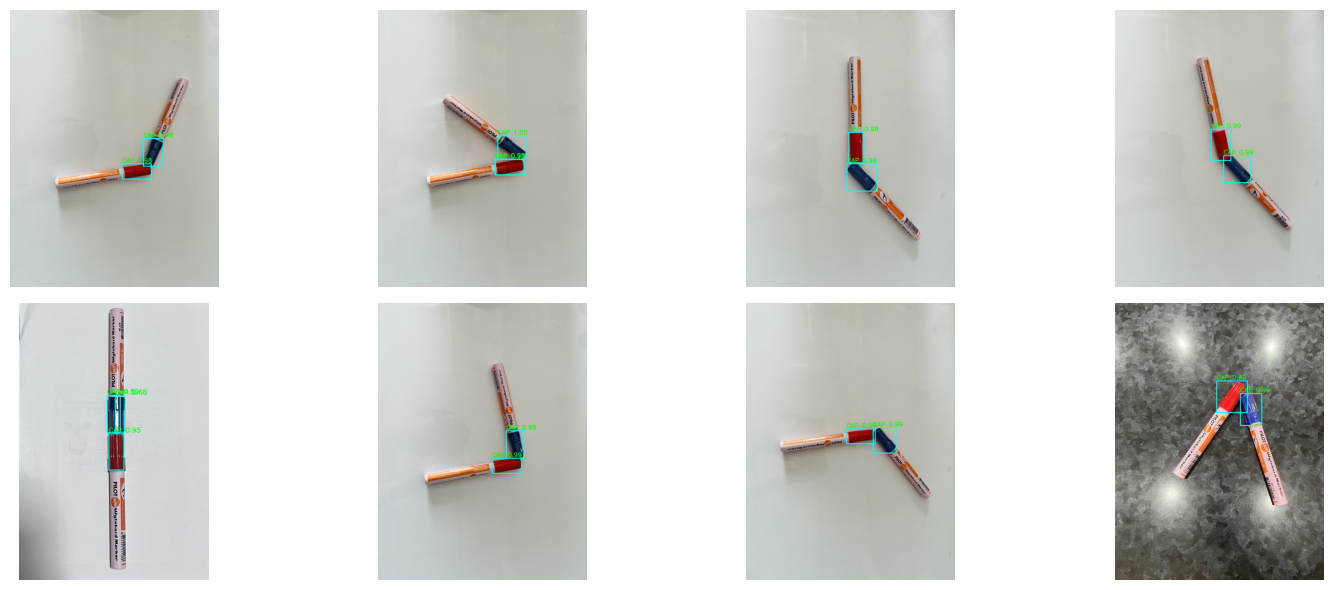

In [ ]:
CONF_THR = 0.5

# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (800, 800))
    img_input = (img_resized[:, :, ::-1].astype(np.float32) ) / 255
    img_input = (img_input - mean) / std
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    result_viz = visualize_results(img, outputs, threshold=CONF_THR)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(result_viz, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()